In [34]:
## 1. Mount Drive + two output folders

# from google.colab import drive
# drive.mount('/content/drive')


from pathlib import Path
DRIVE_ROOT  = Path('/content/drive/MyDrive')
CKPT_DIR    = DRIVE_ROOT/'DACLLwF_checkpoints'
RESULTS_DIR = DRIVE_ROOT/'DACLLwF_results'
FIG_DIR     = RESULTS_DIR/'figures'
for d in (CKPT_DIR,RESULTS_DIR,FIG_DIR): d.mkdir(parents=True,exist_ok=True)
print('checkpoints ->',CKPT_DIR); print('results ->',RESULTS_DIR)

checkpoints -> /content/drive/MyDrive/DACLLwF_checkpoints
results -> /content/drive/MyDrive/DACLLwF_results


In [35]:
## 2. Install
!pip -q install segmentation-models-pytorch==0.3.3 albumentations==1.4.0 2>/dev/null
print('installed')

installed


In [36]:
## 3. Imports + reproducibility
import os,json,random,itertools,warnings
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from PIL import Image
warnings.filterwarnings('ignore')
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
print('Device:',DEVICE)
def seed_everything(s):
    random.seed(s);np.random.seed(s);torch.manual_seed(s);torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic=True;torch.backends.cudnn.benchmark=False
    os.environ['PYTHONHASHSEED']=str(s)
seed_everything(42)

Device: cuda


In [37]:
## 4. CONFIG (paths + hyperparams + DAM variant grid)
from dataclasses import dataclass, asdict
@dataclass
class CFG:
    boreal_root:str='/content/drive/MyDrive/Boreal-Forest-Fire/Boreal-Forest-Fire-Subset-C'
    flame_root :str='/content/drive/MyDrive/FLAME Datasets/FLAME_Split'
    img_size:int=256; batch_size:int=4; epochs:int=30
    lr_backbone:float=1e-4; lr_head:float=1e-3; weight_decay:float=1e-4
    lr_milestones:tuple=(15,24); lr_gamma:float=0.1
    ce_weights:tuple=(1.0,20.0); ce_w:float=0.4; dice_w:float=0.6; num_workers:int=2
    alpha_lwf:float=0.5; gamma_feat:float=0.3; lambda_rep:float=0.5; kd_temp:float=2.0
    delta_coral:float=0.1                 # alignment weight (keep modest)
    base_seed:int=42
    dam_seeds:tuple=(42,)            # >=3 seeds for the paired test
cfg=CFG()
print(json.dumps({k:v for k,v in asdict(cfg).items() if 'root' not in k},indent=2))

{
  "img_size": 256,
  "batch_size": 4,
  "epochs": 30,
  "lr_backbone": 0.0001,
  "lr_head": 0.001,
  "weight_decay": 0.0001,
  "lr_milestones": [
    15,
    24
  ],
  "lr_gamma": 0.1,
  "ce_weights": [
    1.0,
    20.0
  ],
  "ce_w": 0.4,
  "dice_w": 0.6,
  "num_workers": 2,
  "alpha_lwf": 0.5,
  "gamma_feat": 0.3,
  "lambda_rep": 0.5,
  "kd_temp": 2.0,
  "delta_coral": 0.1,
  "base_seed": 42,
  "dam_seeds": [
    42
  ]
}


In [38]:
## 5. Datasets (Boreal T1, FLAME T2) — your actual Drive layout


IM=(0.485,0.456,0.406); IS=(0.229,0.224,0.225)
def train_tf(sz): return A.Compose([A.RandomResizedCrop(sz,sz,scale=(0.8,1.0),ratio=(0.9,1.1)),
    A.HorizontalFlip(0.5),A.Rotate(15,border_mode=cv2.BORDER_CONSTANT,p=0.5),
    A.ColorJitter(0.2,0.2,0.2,0.1,p=0.5),A.RandomGamma((80,120),p=0.3),A.Blur(3,p=0.15),
    A.Normalize(IM,IS),ToTensorV2()])
def eval_tf(sz): return A.Compose([A.Resize(sz,sz),A.Normalize(IM,IS),ToTensorV2()])
class PairDS(Dataset):
    def __init__(s,pairs,tf): s.p=pairs; s.tf=tf
    def __len__(s): return len(s.p)
    def __getitem__(s,i):
        ip,mp=s.p[i]; img=np.array(Image.open(ip).convert('RGB'))
        m=(np.array(Image.open(mp).convert('L'))>0).astype('uint8')
        o=s.tf(image=img,mask=m); return o['image'],o['mask'].long(),str(ip)
def match(idir,mdir,ie='.jpg',me='.png'):
    idir,mdir=Path(idir),Path(mdir)
    im={p.stem:p for p in idir.glob(f'*{ie}')}; mk={p.stem:p for p in mdir.glob(f'*{me}')}
    return [(im[k],mk[k]) for k in sorted(set(im)&set(mk))]
def boreal(root,sp):
    root=Path(root); md=(root/'manual_masks'/'test') if sp=='test' else (root/'sam_masks'/sp)
    return match(root/'images'/sp, md)
def flame(root,sp):
    root=Path(root); return match(root/'images'/sp, root/'masks'/sp)
b_tr,b_va,b_te=boreal(cfg.boreal_root,'train'),boreal(cfg.boreal_root,'valid'),boreal(cfg.boreal_root,'test')
f_tr,f_va,f_te=flame(cfg.flame_root,'train'),flame(cfg.flame_root,'valid'),flame(cfg.flame_root,'test')
print(f'Boreal {len(b_tr)}/{len(b_va)}/{len(b_te)} (expect 1184/248/40)')
print(f'FLAME  {len(f_tr)}/{len(f_va)}/{len(f_te)} (expect 1402/300/301)')
assert len(b_tr) and len(f_tr),'check paths in CFG'
def loader(pairs,train,shuffle=None):
    tf=train_tf(cfg.img_size) if train else eval_tf(cfg.img_size)
    g=torch.Generator();g.manual_seed(cfg.base_seed)
    return DataLoader(PairDS(pairs,tf),batch_size=cfg.batch_size,
        shuffle=train if shuffle is None else shuffle,num_workers=cfg.num_workers,
        pin_memory=True,drop_last=train,generator=g)
t1_train,t1_val,t1_test=loader(b_tr,True),loader(b_va,False),loader(b_te,False)
t2_train,t2_val,t2_test=loader(f_tr,True),loader(f_va,False),loader(f_te,False)

Boreal 1150/227/40 (expect 1184/248/40)
FLAME  1402/300/301 (expect 1402/300/301)


In [39]:
## 6. Domain-Specific BatchNorm (DSBN)
# Per-task BN stats, shared conv weights; routed by known task id (valid for task-incremental).

class DSBN2d(nn.Module):
    def __init__(s,c,tasks=('T1','T2'),**kw):
        super().__init__(); s.bns=nn.ModuleDict({t:nn.BatchNorm2d(c,**kw) for t in tasks}); s._t=tasks[0]
    def set_task(s,t): s._t=t
    def forward(s,x): return s.bns[s._t](x)
def convert_bn_to_dsbn(m,tasks=('T1','T2')):
    for n,ch in list(m.named_children()):
        if isinstance(ch,nn.BatchNorm2d):
            ds=DSBN2d(ch.num_features,tasks,eps=ch.eps,momentum=ch.momentum,
                      affine=ch.affine,track_running_stats=ch.track_running_stats)
            for t in tasks: ds.bns[t].load_state_dict(ch.state_dict())
            setattr(m,n,ds)
        else: convert_bn_to_dsbn(ch,tasks)
    return m
def set_model_task(model,t):
    for mm in model.modules():
        if isinstance(mm,DSBN2d): mm.set_task(t)

In [40]:
## 7. DA-CLLwF model
# DSBN structure is ALWAYS present (keys consistent); `use_dsbn` only controls routing
# (off -> all tasks share the T1 branch = original shared BN; on -> per-task branch).
# A 1x1 align projector feeds CORAL only during training and is discarded at inference.

def _make_head():
    h=nn.Sequential(nn.Conv2d(128,128,3,padding=1,bias=False),nn.BatchNorm2d(128),
        nn.ReLU(True),nn.Dropout2d(0.2),nn.Conv2d(128,2,1))
    for m in h.modules():
        if isinstance(m,nn.Conv2d):
            nn.init.kaiming_normal_(m.weight,mode='fan_out',nonlinearity='relu')
            if m.bias is not None: nn.init.zeros_(m.bias)
    return h
class DACLLwFSegModel(nn.Module):
    def __init__(s,encoder_name='resnet50',encoder_weights='imagenet',tasks=('T1','T2'),
                 use_dsbn=False,align_dim=128):
        super().__init__()
        base=smp.FPN(encoder_name=encoder_name,encoder_weights=encoder_weights,classes=2,
            activation=None,decoder_pyramid_channels=256,decoder_segmentation_channels=128,upsampling=4)
        s.encoder=base.encoder; s.decoder=base.decoder; s.heads=nn.ModuleDict()
        s.use_dsbn=use_dsbn; s.tasks=tasks
        convert_bn_to_dsbn(s.encoder,tasks)                 # ALWAYS
        s.align_proj=nn.Conv2d(s.encoder.out_channels[-1],align_dim,1,bias=False)
    def add_task(s,n):
        if n not in s.heads: s.heads[n]=_make_head()
    def set_task(s,t): set_model_task(s, t if s.use_dsbn else s.tasks[0])
    def extract_features(s,x): return s.encoder(x)
    def forward(s,x,task,return_feat=False,return_align=False):
        s.set_task(task); feats=s.encoder(x); d=s.decoder(*feats)
        lg=F.interpolate(s.heads[task](d),size=x.shape[-2:],mode='bilinear',align_corners=False)
        out=[lg]
        if return_feat: out.append(feats[-1])
        if return_align: out.append(F.adaptive_avg_pool2d(s.align_proj(feats[-1]),8))
        return out[0] if len(out)==1 else tuple(out)
def count_params(m): return sum(p.numel() for p in m.parameters())
# self-test
_m=DACLLwFSegModel(use_dsbn=True).to(DEVICE); _m.add_task('T1')
_m2=DACLLwFSegModel(use_dsbn=False); _m2.add_task('T1')
assert count_params(_m.heads['T1'])==147970
assert set(_m.state_dict())==set(_m2.state_dict()),'key mismatch across use_dsbn'
print('Head params 147,970 OK; keys consistent across use_dsbn. DA-CLLwF model ready.')
del _m,_m2


Head params 147,970 OK; keys consistent across use_dsbn. DA-CLLwF model ready.


In [41]:
## 8. Losses + CORAL + metrics + checkpoint utils

class DiceCE(nn.Module):
    def __init__(s,w,cw,dw): super().__init__(); s.ce=nn.CrossEntropyLoss(weight=torch.tensor(w,dtype=torch.float32)); s.cw,s.dw=cw,dw
    def to(s,d): s.ce.weight=s.ce.weight.to(d); return super().to(d)
    def dice(s,lg,t,eps=1.):
        p=torch.softmax(lg,1)[:,1]; tt=(t==1).float()
        inter=(p*tt).sum((1,2)); union=p.sum((1,2))+tt.sum((1,2))
        return (1-(2*inter+eps)/(union+eps)).mean()
    def forward(s,lg,t): return s.cw*s.ce(lg,t)+s.dw*s.dice(lg,t)
def lwf_kd(sl,tl,T):
    s=F.log_softmax(sl/T,dim=1); t=F.softmax(tl/T,dim=1)
    kl=F.kl_div(s,t,reduction='none').sum(dim=1)
    return kl.mean()*(T*T)
def feat_mse(a,b): return F.mse_loss(a,b)
def coral_loss(fs,ft,eps=1e-5):
    def cov(z):
        z=z.permute(0,2,3,1).reshape(-1,z.shape[1]); z=z-z.mean(0,keepdim=True)
        return (z.t()@z)/max(z.shape[0]-1,1)
    cs,ct=cov(fs),cov(ft); d=fs.shape[1]
    return ((cs-ct)**2).sum()/(4*d*d+eps)
@torch.no_grad()
def evaluate(model,loader,task):
    model.eval(); TP=FP=FN=TN=0; inter=np.zeros(2); union=np.zeros(2); ls=0.;nb=0
    crit=DiceCE(cfg.ce_weights,cfg.ce_w,cfg.dice_w).to(DEVICE)
    for x,y,_ in loader:
        x,y=x.to(DEVICE),y.to(DEVICE); lg=model(x,task); ls+=crit(lg,y).item();nb+=1
        pr=lg.argmax(1)
        for c in range(2):
            pc=(pr==c);tc=(y==c); inter[c]+=(pc&tc).sum().item(); union[c]+=(pc|tc).sum().item()
        p1=(pr==1);t1=(y==1)
        TP+=(p1&t1).sum().item();FP+=(p1&~t1).sum().item();FN+=(~p1&t1).sum().item();TN+=(~p1&~t1).sum().item()
    iou=inter/np.maximum(union,1); prec=TP/max(TP+FP,1);rec=TP/max(TP+FN,1)
    return {'mIoU':float(iou.mean()),'IoU_bg':float(iou[0]),'IoU_fg':float(iou[1]),
            'Dice_fg':float(2*TP/max(2*TP+FP+FN,1)),'pixel_acc':float((TP+TN)/max(TP+TN+FP+FN,1)),
            'precision':float(prec),'recall':float(rec),'loss':float(ls/max(nb,1))}
def ckpt(t): return CKPT_DIR/f'{t}.pt'
def res(t):  return RESULTS_DIR/f'{t}.json'
def save_ckpt(m,t,x=None): torch.save({'model':m.state_dict(),'extra':x or {}},ckpt(t))
def load_ckpt(m,t): st=torch.load(ckpt(t),map_location=DEVICE); m.load_state_dict(st['model'],strict=False); return st.get('extra',{})
def ckpt_exists(t): return ckpt(t).exists()
def save_res(t,d): json.dump(d,open(res(t),'w'),indent=2)
def load_res(t): return json.load(open(res(t)))
def res_exists(t): return res(t).exists()
print('losses+CORAL+metrics+ckpt ready')

losses+CORAL+metrics+ckpt ready


In [42]:
## 9. Generic training loop (+resume) and Stage-1 T1 teacher (trained once)

## 9. Generic training loop (+per-epoch resume) and Stage-1 T1 teacher (trained once)

## 9. Generic training loop (+per-epoch resume) and Stage-1 T1 teacher (trained once)

def build_opt(m):
    hp=[p for n,p in m.named_parameters() if n.startswith('heads.')]
    bp=[p for n,p in m.named_parameters() if not n.startswith('heads.')]
    return torch.optim.AdamW([{'params':bp,'lr':cfg.lr_backbone},{'params':hp,'lr':cfg.lr_head}],weight_decay=cfg.weight_decay)

@torch.no_grad()
def _train_metrics(model,loader,task,max_batches=40):
    """Quick train-set mIoU/loss on a few batches (so per-epoch train accuracy is visible)."""
    return evaluate_subset(model,loader,task,max_batches)

@torch.no_grad()
def evaluate_subset(model,loader,task,max_batches=40):
    model.eval(); TP=FP=FN=TN=0; inter=np.zeros(2); union=np.zeros(2); ls=0.;nb=0
    crit=DiceCE(cfg.ce_weights,cfg.ce_w,cfg.dice_w).to(DEVICE)
    for x,y,_ in loader:
        x,y=x.to(DEVICE),y.to(DEVICE); lg=model(x,task); ls+=crit(lg,y).item();nb+=1
        pr=lg.argmax(1)
        for c in range(2):
            pc=(pr==c);tc=(y==c); inter[c]+=(pc&tc).sum().item(); union[c]+=(pc|tc).sum().item()
        p1=(pr==1);t1=(y==1)
        TP+=(p1&t1).sum().item();FP+=(p1&~t1).sum().item();FN+=(~p1&t1).sum().item();TN+=(~p1&~t1).sum().item()
        if nb>=max_batches: break
    iou=inter/np.maximum(union,1)
    return {'mIoU':float(iou.mean()),'IoU_fg':float(iou[1]),
            'pixel_acc':float((TP+TN)/max(TP+TN+FP+FN,1)),'loss':float(ls/max(nb,1))}

def train_task(model,task,tl,vl,tag,seed,t2_obj=None):
    seed_everything(seed)
    if ckpt_exists(tag) and res_exists(tag): print(f'[skip] {tag} (already finished)'); return load_res(tag)
    model=model.to(DEVICE)                              # ensure whole model (DSBN + align_proj + heads) on GPU
    crit=DiceCE(cfg.ce_weights,cfg.ce_w,cfg.dice_w).to(DEVICE)
    opt=build_opt(model)
    sch=torch.optim.lr_scheduler.MultiStepLR(opt,cfg.lr_milestones,cfg.lr_gamma)

    epoch_tag=tag+'__epoch'                             # per-epoch resume checkpoint
    start_ep=0; best=-1.0; hist=[]
    if ckpt_exists(epoch_tag):
        ex=torch.load(ckpt(epoch_tag),map_location=DEVICE)
        model.load_state_dict(ex['model'],strict=False)
        opt.load_state_dict(ex['opt']); sch.load_state_dict(ex['sch'])
        start_ep=ex['epoch']+1; best=ex['best']; hist=ex['hist']
        print(f'[resume] {tag} from epoch {start_ep} (best val mIoU so far {best:.4f})')

    for ep in range(start_ep,cfg.epochs):
        model.train();run=0.;nb=0
        for x,y,_ in tl:
            x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True)
            opt.zero_grad();lg=model(x,task);loss=crit(lg,y)
            if t2_obj is not None: loss=loss+t2_obj(model,x,y)
            loss.backward();opt.step();run+=loss.item();nb+=1
        sch.step()
        tr=_train_metrics(model,tl,task)                # train accuracy/mIoU (subset, fast)
        v =evaluate(model,vl,task)                      # full validation
        improved = v['mIoU']>best
        if improved: best=v['mIoU']; save_ckpt(model,tag,{'ep':ep,'val':v})   # best model
        hist.append({'ep':ep,'train_loss':run/max(nb,1),'train_mIoU':tr['mIoU'],
                     'train_acc':tr['pixel_acc'],'val_mIoU':v['mIoU'],'val_acc':v['pixel_acc'],'val_loss':v['loss']})
        # per-epoch resume checkpoint (full state)
        torch.save({'model':model.state_dict(),'opt':opt.state_dict(),'sch':sch.state_dict(),
                    'epoch':ep,'best':best,'hist':hist}, ckpt(epoch_tag))
        print(f'  ep{ep:02d} | train loss {run/max(nb,1):.4f}  train mIoU {tr["mIoU"]:.4f}  train acc {tr["pixel_acc"]:.4f}'
              f'  ||  val mIoU {v["mIoU"]:.4f}  val acc {v["pixel_acc"]:.4f}{"  *best" if improved else ""}')

    load_ckpt(model,tag)                                # reload best
    s={'tag':tag,'best_val_mIoU':best,'hist':hist}; save_res(tag,s)
    if ckpt(epoch_tag).exists(): ckpt(epoch_tag).unlink()   # cleanup per-epoch ckpt once finished
    return s

T1_TAG=f'T1_teacher_s{cfg.base_seed}'
model=DACLLwFSegModel(use_dsbn=False).to(DEVICE); model.add_task('T1'); model=model.to(DEVICE)
train_task(model,'T1',t1_train,t1_val,T1_TAG,cfg.base_seed)
if res_exists('T1_before'): t1_before=load_res('T1_before')
else:
    load_ckpt(model,T1_TAG); model=model.to(DEVICE); t1_before=evaluate(model,t1_test,'T1'); save_res('T1_before',t1_before)
print('T1 test (before T2):',{k:round(v,4) for k,v in t1_before.items()})

[skip] T1_teacher_s42 (already finished)
T1 test (before T2): {'mIoU': 0.8651, 'IoU_bg': 0.9274, 'IoU_fg': 0.8028, 'Dice_fg': 0.8906, 'pixel_acc': 0.944, 'precision': 0.919, 'recall': 0.8639, 'loss': 0.4023}


In [43]:
## 10. DA-CLLwF Stage-2 runner (flags drive every variant)
# Extends the CLLwF T2 objective with DAM terms:
# `use_dsbn` (per-task BN routing) and `use_coral` (alignment on replay-interleaved steps, weight delta).

def freeze(m):
    for p in m.parameters(): p.requires_grad=False
def make_teacher(use_dsbn):
    t=DACLLwFSegModel(use_dsbn=use_dsbn).to(DEVICE); t.add_task('T1'); load_ckpt(t,T1_TAG); t=t.to(DEVICE); t.eval(); freeze(t); return t
def replay_loader(n,seed):
    rng=np.random.default_rng(seed); idx=sorted(rng.choice(len(b_tr),min(n,len(b_tr)),replace=False).tolist())
    return loader([b_tr[i] for i in idx],True), idx
def run_t2_dam(tag,seed,f):
    if res_exists(tag): print(f'[skip] {tag}'); return load_res(tag)
    seed_everything(seed); ud=f.get('use_dsbn',False)
    st=DACLLwFSegModel(use_dsbn=ud).to(DEVICE); st.add_task('T1'); st.add_task('T2'); load_ckpt(st,T1_TAG); st=st.to(DEVICE)
    if f.get('freeze_t1_head',True): freeze(st.heads['T1'])
    tc=make_teacher(ud); rit=None
    if f.get('use_replay'): rl,_=replay_loader(300,seed); rit=itertools.cycle(rl)
    rcrit=DiceCE(cfg.ce_weights,cfg.ce_w,cfg.dice_w).to(DEVICE)
    def obj(m,x,y):
        e=0.0
        if f.get('use_lwf') or f.get('use_feat'):
            with torch.no_grad(): tl,tf=tc(x,'T1',return_feat=True)
            sl,sf=m(x,'T1',return_feat=True)
            if f.get('use_lwf'):  e=e+cfg.alpha_lwf*lwf_kd(sl,tl,cfg.kd_temp)
            if f.get('use_feat'): e=e+cfg.gamma_feat*feat_mse(sf,tf)
        if rit is not None:
            rx,ry,_=next(rit); rx,ry=rx.to(DEVICE),ry.to(DEVICE)
            e=e+cfg.lambda_rep*rcrit(m(rx,'T1'),ry)
            if f.get('use_coral'):
                a2=m(x,'T2',return_align=True)[-1]; a1=m(rx,'T1',return_align=True)[-1]
                e=e+cfg.delta_coral*coral_loss(a1,a2)
        return e
    train_task(st,'T2',t2_train,t2_val,tag,seed,t2_obj=obj)
    load_ckpt(st,tag); t2=evaluate(st,t2_test,'T2'); t1a=evaluate(st,t1_test,'T1')
    a1,a2,b=t1_before['mIoU'],t1a['mIoU'],t2['mIoU']
    r={'tag':tag,'seed':seed,'flags':f,'T1_after':a2,'T2':b,'BWT':a2-a1,
       'retention':100*a2/a1,'avg':(a2+b)/2,
       'T1_metrics':t1a,'T2_metrics':t2}
    save_res(tag,r); print(f'  -> T1_after {a2:.4f} T2 {b:.4f} avg {(a2+b)/2:.4f} ret {100*a2/a1:.2f}%')
    return r
print('DA-CLLwF runner ready')

DA-CLLwF runner ready


In [44]:
# ## 10b. (Run ONCE) Clear bad DAM runs after fixing the LwF loss
# Only needed if you already ran variants with the old (broken) LwF. Keeps the T1 teacher.
# # Delete bad DAM checkpoints + results so they retrain with the fixed LwF loss. Keeps T1 teacher.

# import glob, os
# removed=0
# for pat in [str(CKPT_DIR/'DAM_*'), str(RESULTS_DIR/'DAM_*.json')]:
#     for p in glob.glob(pat): os.remove(p); removed+=1
# for p in glob.glob(str(CKPT_DIR/'*__epoch.pt')):
#     if 'DAM_' in os.path.basename(p): os.remove(p); removed+=1
# print(f'Deleted {removed} bad DAM files. T1 teacher kept:',(CKPT_DIR/f'T1_teacher_s{cfg.base_seed}.pt').exists())

In [45]:
## 11. Run the 5 variants x seeds (resume-safe)
# * `replay_only` — LwF+replay (the baseline DAM must beat)
# * `cllwf` — full CLLwF (your current method)
# * `dam_dsbn` — CLLwF + DSBN only
# * `dam_coral` — CLLwF + CORAL only
# * `dam_full` — CLLwF + DSBN + CORAL  (**proposed DA-CLLwF**)

# Two levels of resume:
#   - variant-level: a finished variant (result JSON exists) is SKIPPED.
#   - epoch-level  : if a variant stops mid-training, re-running this cell resumes it
#                    from the exact epoch it stopped at (model+optimizer+scheduler restored).
# Just RE-RUN this cell after any disconnect; it continues where it left off.

VARIANTS={
 'replay_only':dict(use_lwf=True,use_feat=False,use_replay=True,freeze_t1_head=False,use_dsbn=False,use_coral=False),
 'cllwf':      dict(use_lwf=True,use_feat=True, use_replay=True,freeze_t1_head=True, use_dsbn=False,use_coral=False),
 'dam_dsbn':   dict(use_lwf=True,use_feat=True, use_replay=True,freeze_t1_head=True, use_dsbn=True, use_coral=False),
 'dam_coral':  dict(use_lwf=True,use_feat=True, use_replay=True,freeze_t1_head=True, use_dsbn=False,use_coral=True),
 'dam_full':   dict(use_lwf=True,use_feat=True, use_replay=True,freeze_t1_head=True, use_dsbn=True, use_coral=True),
}

def _mech_str(f):
    on=[k.replace('use_','').upper() for k in ['use_lwf','use_feat','use_replay','use_dsbn','use_coral'] if f.get(k)]
    on.append('FREEZE-T1' if f.get('freeze_t1_head') else 'no-freeze')
    return ' + '.join(on)

import pandas as pd
total=len(VARIANTS)*len(cfg.dam_seeds); k=0; done=[]
for name,f in VARIANTS.items():
    for s in cfg.dam_seeds:
        k+=1; tag=f'DAM_{name}_s{s}'
        # status line (finished / will-resume / fresh)
        status='FINISHED (skip)' if res_exists(tag) else ('RESUME from epoch checkpoint' if ckpt_exists(tag+'__epoch') else 'fresh start')
        print(f'\n{"="*72}\n[{k}/{total}] {tag}   [ {_mech_str(f)} ]   -> {status}\n{"="*72}')
        r=run_t2_dam(tag,s,f)
        done.append({'variant':name,'seed':s,'T1_after':round(r["T1_after"],4),
                     'T2':round(r["T2"],4),'avg':round(r["avg"],4),'retention':round(r["retention"],2)})
        print('\n--- results so far ---'); print(pd.DataFrame(done).to_string(index=False))

print('\nStage-1 variants complete.')


[1/5] DAM_replay_only_s42   [ LWF + REPLAY + no-freeze ]   -> FINISHED (skip)
[skip] DAM_replay_only_s42

--- results so far ---
    variant  seed  T1_after     T2    avg  retention
replay_only    42    0.8583 0.8043 0.8313      99.21

[2/5] DAM_cllwf_s42   [ LWF + FEAT + REPLAY + FREEZE-T1 ]   -> FINISHED (skip)
[skip] DAM_cllwf_s42

--- results so far ---
    variant  seed  T1_after     T2    avg  retention
replay_only    42    0.8583 0.8043 0.8313      99.21
      cllwf    42    0.8526 0.8053 0.8290      98.56

[3/5] DAM_dam_dsbn_s42   [ LWF + FEAT + REPLAY + DSBN + FREEZE-T1 ]   -> FINISHED (skip)
[skip] DAM_dam_dsbn_s42

--- results so far ---
    variant  seed  T1_after     T2    avg  retention
replay_only    42    0.8583 0.8043 0.8313      99.21
      cllwf    42    0.8526 0.8053 0.8290      98.56
   dam_dsbn    42    0.8547 0.8146 0.8346      98.80

[4/5] DAM_dam_coral_s42   [ LWF + FEAT + REPLAY + CORAL + FREEZE-T1 ]   -> FINISHED (skip)
[skip] DAM_dam_coral_s42

--- results 

In [46]:
## 12. Go / No-Go analysis (paired significance: dam_full vs replay_only)

import pandas as pd
from scipy import stats
rows=[]
for name in VARIANTS:
    for s in cfg.dam_seeds:
        tag=f'DAM_{name}_s{s}'
        if res_exists(tag):
            r=load_res(tag); rows.append({'variant':name,'seed':s,'T1_after':r['T1_after'],
                'T2':r['T2'],'avg':r['avg'],'retention':r['retention']})
df=pd.DataFrame(rows)
if len(df):
    agg=(df.groupby('variant').agg(T1_after=('T1_after','mean'),T2=('T2','mean'),
         avg=('avg','mean'),avg_sd=('avg','std'),retention=('retention','mean'),n=('seed','count'))
         .reindex(list(VARIANTS)))
    agg.to_csv(RESULTS_DIR/'dam_stage1_summary.csv'); print(agg.round(4).to_string()); print()
    base=df[df.variant=='replay_only'].sort_values('seed')['avg'].values
    full=df[df.variant=='dam_full'].sort_values('seed')['avg'].values
    if len(base)==len(full)>=2:
        d=full.mean()-base.mean()
        try: _,p=stats.wilcoxon(full,base)
        except Exception: _,p=stats.ttest_rel(full,base)
        ret_ok=agg.loc['dam_full','retention']>=agg.loc['replay_only','retention']-0.5
        print(f'dam_full - replay_only : delta_avg={d:+.4f} mIoU  p={p:.4f}  retention_ok={ret_ok}')
        GO=(d>=0.005)and(p<0.05)and ret_ok
        print('\n'+('*** GO  -> scale to Res2Net-50 / MiT-B2 and write the full paper.'
                    if GO else '*** NO-GO -> pivot to the "when does alignment help vs hurt" analysis paper.'))
        print('   (threshold: delta_avg>=+0.005 AND p<0.05 AND retention preserved)')
else: print('No DAM results yet - run cell 11.')

             T1_after      T2     avg  avg_sd  retention  n
variant                                                    
replay_only    0.8583  0.8043  0.8313     NaN    99.2131  1
cllwf          0.8526  0.8053  0.8290     NaN    98.5553  1
dam_dsbn       0.8547  0.8146  0.8346     NaN    98.7971  1
dam_coral      0.8457  0.7957  0.8207     NaN    97.7569  1
dam_full       0.8431  0.8083  0.8257     NaN    97.4506  1



In [47]:
# ═══════════════════════════════════════════════════════════════════════════
#  DSBN significance test: dam_dsbn vs replay_only across seeds 42, 43, 44
#  Runs ONLY these two variants on the extra seeds (resume-safe, skips finished).
#  Then does a paired test on avg mIoU. Run this cell on its own.
# ═══════════════════════════════════════════════════════════════════════════
from scipy import stats
import pandas as pd, numpy as np

SIG_SEEDS = (42, 43, 44)
SIG_VARIANTS = {
    'replay_only': dict(use_lwf=True, use_feat=False, use_replay=True, freeze_t1_head=False, use_dsbn=False, use_coral=False),
    'dam_dsbn':    dict(use_lwf=True, use_feat=True,  use_replay=True, freeze_t1_head=True,  use_dsbn=True,  use_coral=False),
}

# ---- run (resume-safe: finished tags are skipped; interrupted ones resume) ----
for name, f in SIG_VARIANTS.items():
    for s in SIG_SEEDS:
        tag = f'DAM_{name}_s{s}'
        status = 'FINISHED (skip)' if res_exists(tag) else ('RESUME' if ckpt_exists(tag+'__epoch') else 'fresh')
        print(f'\n{"="*70}\n{tag}  ->  {status}\n{"="*70}')
        run_t2_dam(tag, s, f)

# ---- collect results ----
rows = []
for name in SIG_VARIANTS:
    for s in SIG_SEEDS:
        tag = f'DAM_{name}_s{s}'
        if res_exists(tag):
            r = load_res(tag)
            rows.append({'variant': name, 'seed': s, 'T1_after': r['T1_after'],
                         'T2': r['T2'], 'avg': r['avg'], 'retention': r['retention']})
df = pd.DataFrame(rows)
print('\n================ PER-SEED RESULTS ================')
print(df.to_string(index=False))

# ---- mean ± std ----
print('\n================ MEAN ± STD ================')
for name in SIG_VARIANTS:
    d = df[df.variant == name]
    if len(d):
        print(f"{name:12s}  avg {d['avg'].mean():.4f} ± {d['avg'].std():.4f}   "
              f"T2 {d['T2'].mean():.4f} ± {d['T2'].std():.4f}   "
              f"T1_after {d['T1_after'].mean():.4f} ± {d['T1_after'].std():.4f}   (n={len(d)})")

# ---- paired significance test: dam_dsbn vs replay_only ----
print('\n================ PAIRED SIGNIFICANCE (dam_dsbn vs replay_only) ================')
base = df[df.variant=='replay_only'].sort_values('seed')
dsbn = df[df.variant=='dam_dsbn'].sort_values('seed')
common = sorted(set(base.seed) & set(dsbn.seed))
if len(common) >= 2:
    for metric in ['avg', 'T2', 'T1_after']:
        b = base[base.seed.isin(common)].sort_values('seed')[metric].values
        d = dsbn[dsbn.seed.isin(common)].sort_values('seed')[metric].values
        diff = d.mean() - b.mean()
        t, p_t = stats.ttest_rel(d, b)
        try:
            _, p_w = stats.wilcoxon(d, b)
        except Exception:
            p_w = float('nan')
        sig = 'SIGNIFICANT' if (p_t < 0.05 and diff > 0) else 'not significant'
        print(f"  {metric:9s}  dam_dsbn {d.mean():.4f}  vs  replay_only {b.mean():.4f}  "
              f"| diff {diff:+.4f}  | t-test p={p_t:.4f}  wilcoxon p={p_w:.4f}  -> {sig}")
    print(f"\n  (seeds used: {common})")
    # verdict
    b = base[base.seed.isin(common)].sort_values('seed')['avg'].values
    d = dsbn[dsbn.seed.isin(common)].sort_values('seed')['avg'].values
    diff = d.mean()-b.mean(); _, p = stats.ttest_rel(d, b)
    GO = (diff >= 0.003) and (p < 0.05)
    print('\n' + ('*** DSBN GO: consistent + significant improvement -> write the DSBN finding paper.'
                  if GO else
                  '*** DSBN NO-GO: improvement is within noise -> DSBN is not a reliable win.'))
    print('   (verdict on avg mIoU: needs diff>=+0.003 AND paired t-test p<0.05)')
else:
    print('Need at least 2 common seeds for both variants — let the runs finish.')


DAM_replay_only_s42  ->  FINISHED (skip)
[skip] DAM_replay_only_s42

DAM_replay_only_s43  ->  FINISHED (skip)
[skip] DAM_replay_only_s43

DAM_replay_only_s44  ->  FINISHED (skip)
[skip] DAM_replay_only_s44

DAM_dam_dsbn_s42  ->  FINISHED (skip)
[skip] DAM_dam_dsbn_s42

DAM_dam_dsbn_s43  ->  FINISHED (skip)
[skip] DAM_dam_dsbn_s43

DAM_dam_dsbn_s44  ->  FINISHED (skip)
[skip] DAM_dam_dsbn_s44

================ PER-SEED RESULTS ================
    variant  seed  T1_after       T2      avg  retention
replay_only    42  0.858304 0.804292 0.831298  99.213146
replay_only    43  0.856378 0.801579 0.828978  98.990556
replay_only    44  0.869592 0.798527 0.834059 100.518009
   dam_dsbn    42  0.854704 0.814590 0.834647  98.797091
   dam_dsbn    43  0.858330 0.812164 0.835247  99.216137
   dam_dsbn    44  0.858611 0.808672 0.833642  99.248707

================ MEAN ± STD ================
replay_only   avg 0.8314 ± 0.0025   T2 0.8015 ± 0.0029   T1_after 0.8614 ± 0.0071   (n=3)
dam_dsbn      avg

In [48]:
## 14. Visualizations (paper-ready figures)
# All figures are saved to `DACLLwF_results/figures/` at 300 DPI. Run after the variants (cell 11).
# These become your paper's figures: training curves, method comparison, metric breakdown,
# retention, and qualitative predictions.



In [49]:
### 14a. Training loss & validation mIoU curves (proposed DA-CLLwF, seed 42)
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi':110,'savefig.dpi':300,'font.size':11})

def load_hist(tag):
    return load_res(tag).get('hist',[]) if res_exists(tag) else []

tag=f'DAM_dam_full_s{cfg.base_seed}'
h=load_hist(tag)
if h:
    ep=[x['ep'] for x in h]; tl=[x.get('train_loss') for x in h]; vm=[x['val_mIoU'] for x in h]
    fig,ax=plt.subplots(1,2,figsize=(12,4.2))
    ax[0].plot(ep,tl,'o-',color='#d1495b'); ax[0].set_title('Training loss'); ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss'); ax[0].grid(alpha=.3)
    ax[1].plot(ep,vm,'s-',color='#2e86ab'); ax[1].set_title('Validation mIoU'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('mIoU'); ax[1].grid(alpha=.3)
    plt.suptitle('DA-CLLwF (dam_full) — T2 training',y=1.02); plt.tight_layout()
    plt.savefig(FIG_DIR/'fig_training_curves.png',bbox_inches='tight'); plt.show()
    print('saved',FIG_DIR/'fig_training_curves.png')
else:
    print('Run cell 11 first (no history for',tag,')')

Run cell 11 first (no history for DAM_dam_full_s42 )


In [50]:
### 14b. Aggregate all variants (mean ± std over seeds)

import pandas as pd, numpy as np
recs=[]
for name in VARIANTS:
    for s in cfg.dam_seeds:
        t=f'DAM_{name}_s{s}'
        if res_exists(t):
            r=load_res(t)
            row={'variant':name,'seed':s,'T1_after':r['T1_after'],'T2':r['T2'],
                 'avg':r['avg'],'retention':r['retention'],'BWT':r['BWT']}
            for k in ['Dice_fg','precision','recall','IoU_fg']:
                row[f'T1_{k}']=r.get('T1_metrics',{}).get(k,np.nan)
                row[f'T2_{k}']=r.get('T2_metrics',{}).get(k,np.nan)
            recs.append(row)
D=pd.DataFrame(recs)
LABELS={'replay_only':'LwF+Replay','cllwf':'CLLwF','dam_dsbn':'+DSBN','dam_coral':'+CORAL','dam_full':'DA-CLLwF'}
order=list(VARIANTS)
G=D.groupby('variant')
mean=G.mean(numeric_only=True).reindex(order); std=G.std(numeric_only=True).reindex(order)
print(mean[['T1_after','T2','avg','retention']].round(4).to_string())

             T1_after      T2     avg  retention
variant                                         
replay_only    0.8583  0.8043  0.8313    99.2131
cllwf          0.8526  0.8053  0.8290    98.5553
dam_dsbn       0.8547  0.8146  0.8346    98.7971
dam_coral      0.8457  0.7957  0.8207    97.7569
dam_full       0.8431  0.8083  0.8257    97.4506


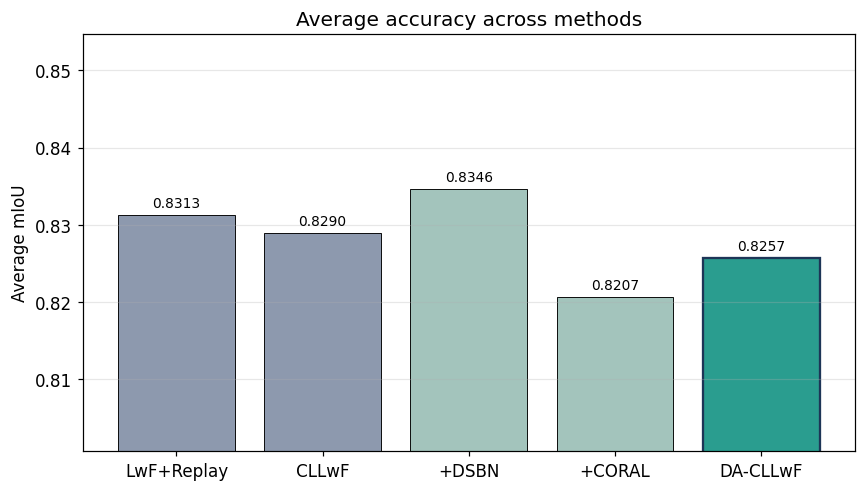

saved /content/drive/MyDrive/DACLLwF_results/figures/fig_avg_comparison.png


In [51]:
### 14c. Method comparison — average mIoU (error bars = std over seeds)

xs=np.arange(len(order)); labels=[LABELS[o] for o in order]
colors=['#8d99ae','#8d99ae','#a3c4bc','#a3c4bc','#2a9d8f']
fig,ax=plt.subplots(figsize=(8,4.6))
bars=ax.bar(xs,mean['avg'],yerr=std['avg'],capsize=5,color=colors,edgecolor='black',linewidth=.6)
for i,b in enumerate(bars):
    ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.001,f"{mean['avg'].iloc[i]:.4f}",ha='center',fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(labels); ax.set_ylabel('Average mIoU')
ax.set_title('Average accuracy across methods'); ax.set_ylim(mean['avg'].min()-0.02, mean['avg'].max()+0.02)
ax.grid(axis='y',alpha=.3)
# highlight the proposed
bars[-1].set_color('#2a9d8f'); bars[-1].set_edgecolor('#1d3557'); bars[-1].set_linewidth(1.5)
plt.tight_layout(); plt.savefig(FIG_DIR/'fig_avg_comparison.png',bbox_inches='tight'); plt.show()
print('saved',FIG_DIR/'fig_avg_comparison.png')

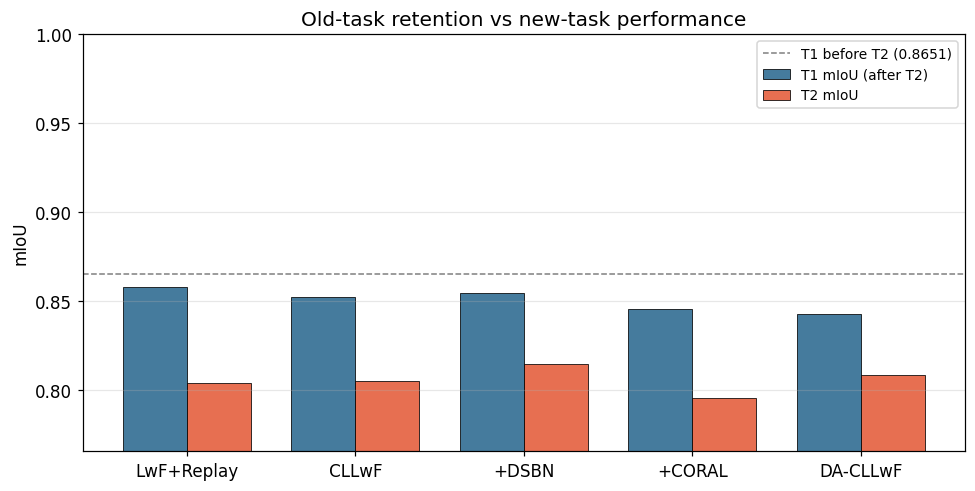

saved /content/drive/MyDrive/DACLLwF_results/figures/fig_retention_vs_newtask.png


In [52]:
### 14d. T1 retention (after T2) and T2 mIoU per method

w=0.38
fig,ax=plt.subplots(figsize=(9,4.6))
b1=ax.bar(xs-w/2,mean['T1_after'],w,yerr=std['T1_after'],capsize=4,label='T1 mIoU (after T2)',color='#457b9d',edgecolor='black',linewidth=.5)
b2=ax.bar(xs+w/2,mean['T2'],w,yerr=std['T2'],capsize=4,label='T2 mIoU',color='#e76f51',edgecolor='black',linewidth=.5)
ax.axhline(t1_before['mIoU'],ls='--',color='grey',lw=1,label=f"T1 before T2 ({t1_before['mIoU']:.4f})")
ax.set_xticks(xs); ax.set_xticklabels(labels); ax.set_ylabel('mIoU'); ax.legend(fontsize=9)
ax.set_title('Old-task retention vs new-task performance'); ax.grid(axis='y',alpha=.3)
ax.set_ylim(min(mean['T2'].min(),mean['T1_after'].min())-0.03,1.0)
plt.tight_layout(); plt.savefig(FIG_DIR/'fig_retention_vs_newtask.png',bbox_inches='tight'); plt.show()
print('saved',FIG_DIR/'fig_retention_vs_newtask.png')

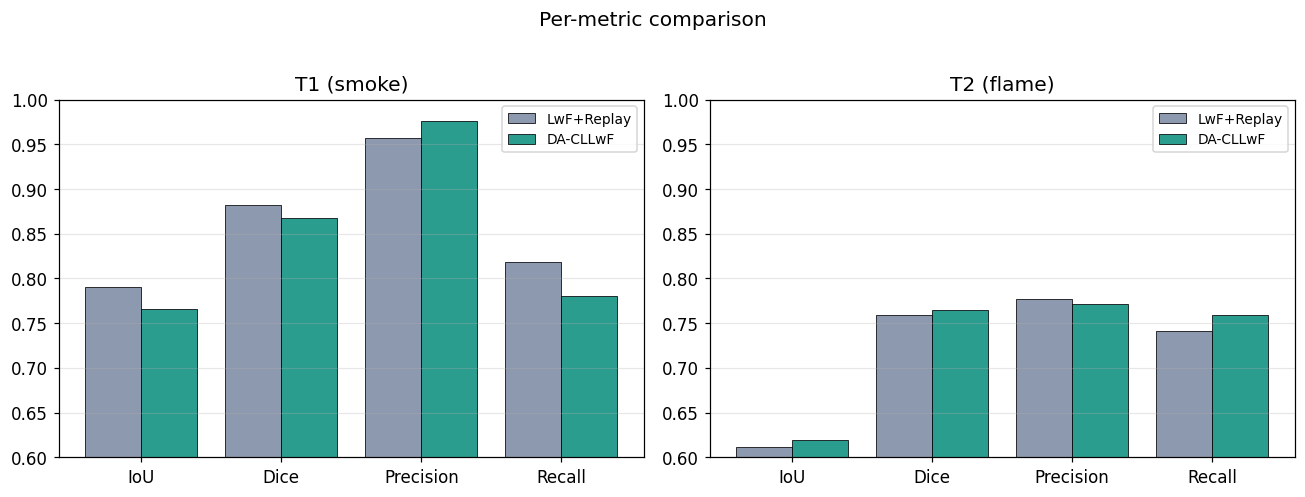

saved /content/drive/MyDrive/DACLLwF_results/figures/fig_metric_breakdown.png


In [53]:
### 14e. Detailed metrics — DA-CLLwF vs LwF+Replay (T1 and T2)

mets=['IoU_fg','Dice_fg','precision','recall']; nm=['IoU','Dice','Precision','Recall']
prop='dam_full'; base='replay_only'
fig,ax=plt.subplots(1,2,figsize=(12,4.4))
for j,(task,pfx) in enumerate([('T1','T1_'),('T2','T2_')]):
    xm=np.arange(len(mets))
    pv=[mean.loc[prop,pfx+m] for m in mets]; bv=[mean.loc[base,pfx+m] for m in mets]
    ax[j].bar(xm-0.2,bv,0.4,label='LwF+Replay',color='#8d99ae',edgecolor='black',linewidth=.5)
    ax[j].bar(xm+0.2,pv,0.4,label='DA-CLLwF',color='#2a9d8f',edgecolor='black',linewidth=.5)
    ax[j].set_xticks(xm); ax[j].set_xticklabels(nm); ax[j].set_title(f'{task} ({"smoke" if task=="T1" else "flame"})')
    ax[j].set_ylim(0.6,1.0); ax[j].grid(axis='y',alpha=.3); ax[j].legend(fontsize=9)
plt.suptitle('Per-metric comparison',y=1.02); plt.tight_layout()
plt.savefig(FIG_DIR/'fig_metric_breakdown.png',bbox_inches='tight'); plt.show()
print('saved',FIG_DIR/'fig_metric_breakdown.png')

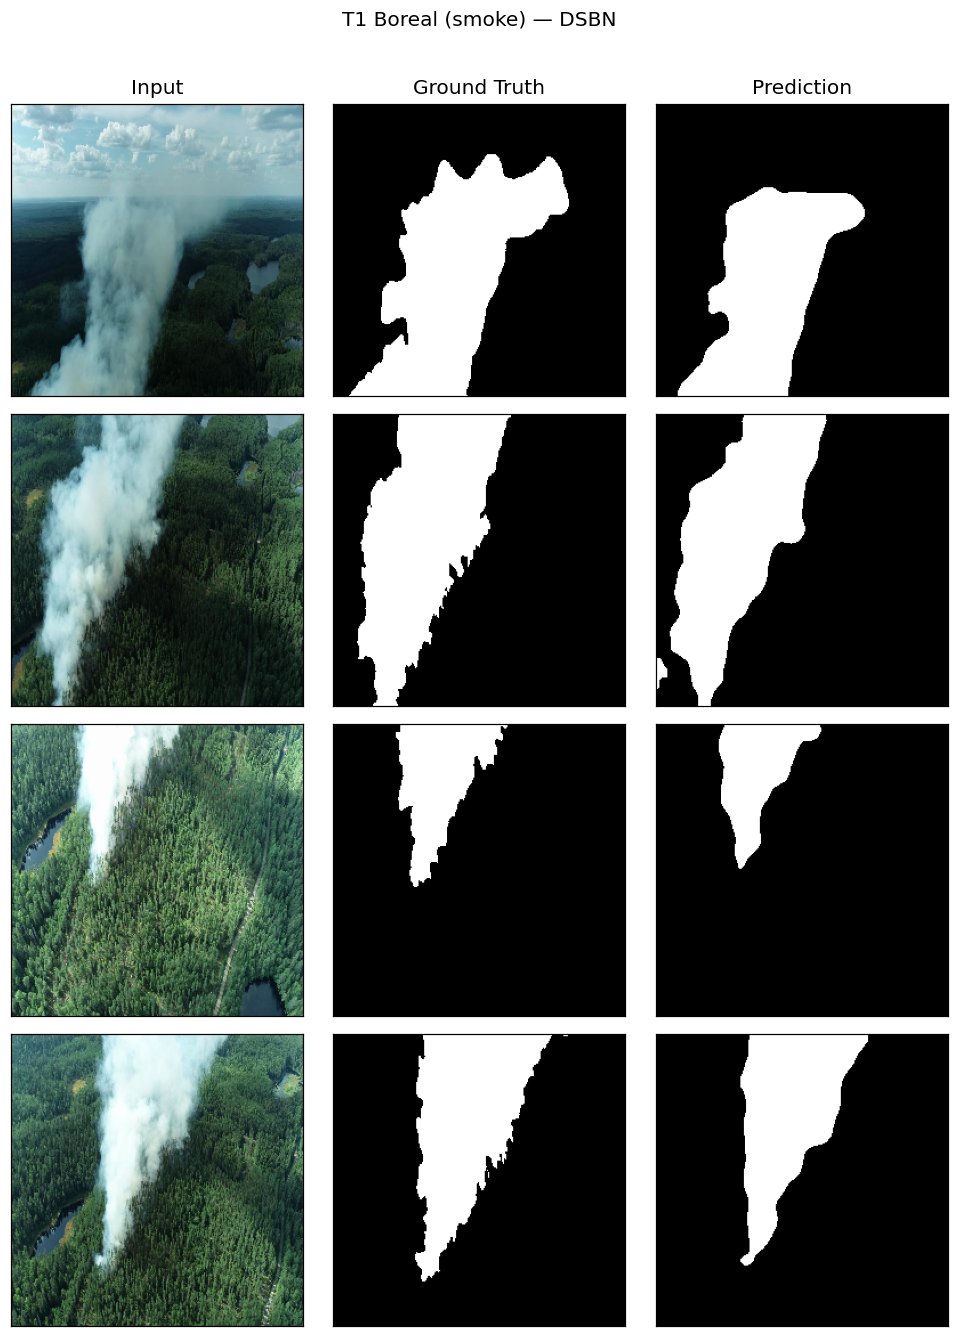

saved /content/drive/MyDrive/DACLLwF_results/figures/fig_qual_T1_smoke.png


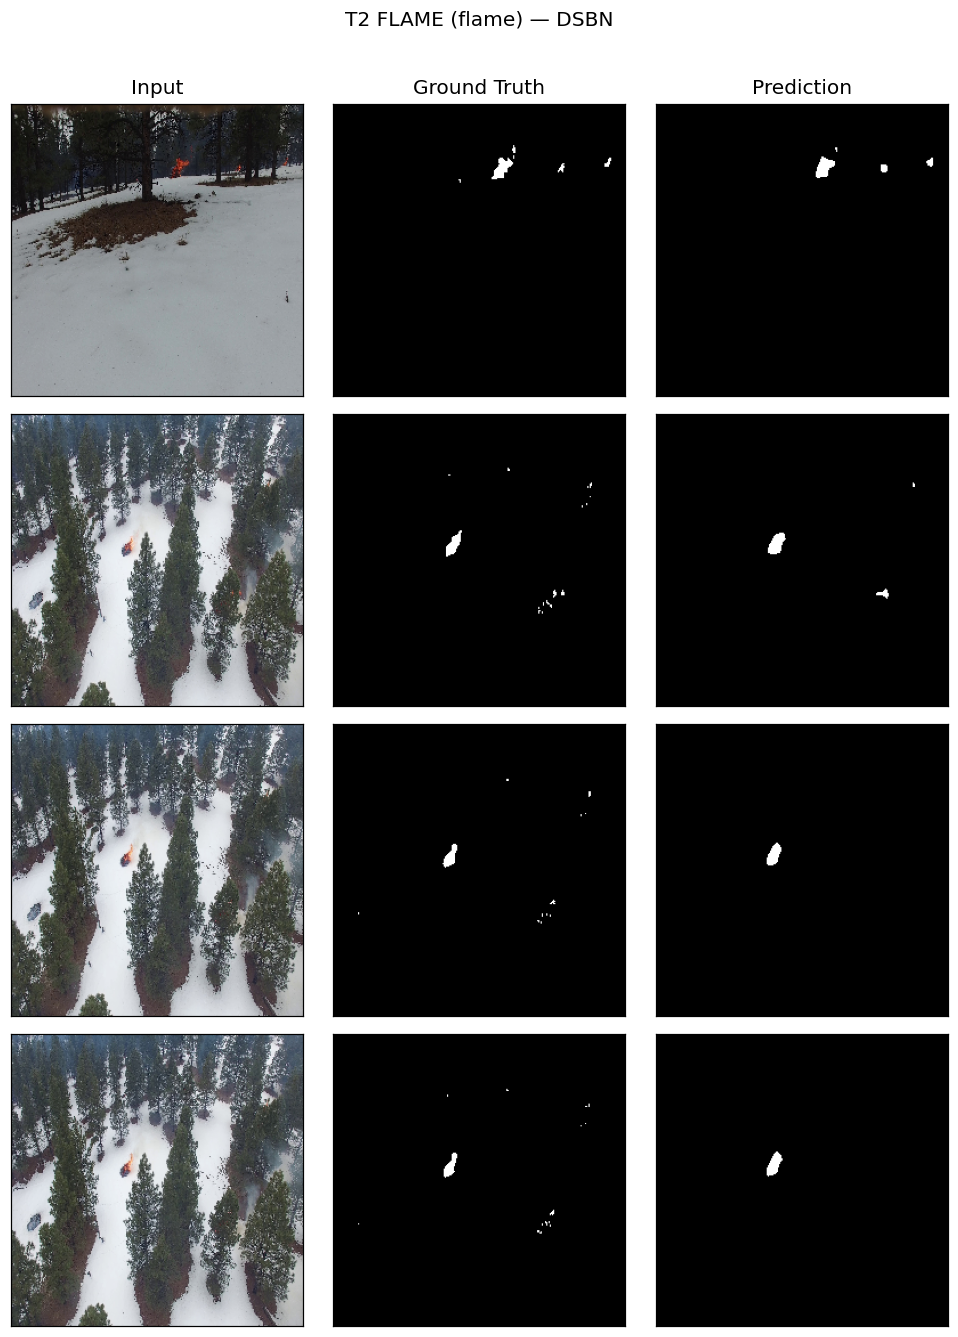

saved /content/drive/MyDrive/DACLLwF_results/figures/fig_qual_T2_flame.png


In [55]:
### 14f. Qualitative predictions (input, ground truth, prediction)

@torch.no_grad()
def show_predictions(tag, pairs, task, n=4, fname='fig_qualitative.png', title='', use_dsbn=False):
    if not ckpt_exists(tag): print('no checkpoint',tag); return
    m=DACLLwFSegModel(use_dsbn=use_dsbn).to(DEVICE)
    m.add_task('T1'); m.add_task('T2'); load_ckpt(m,tag); m=m.to(DEVICE); m.eval()   # <-- .to(DEVICE) after add_task
    tf=eval_tf(cfg.img_size); sel=pairs[:n]
    fig,ax=plt.subplots(n,3,figsize=(9,3*n))
    inv_m=np.array(IM); inv_s=np.array(IS)
    for i,(ip,mp) in enumerate(sel):
        img=np.array(Image.open(ip).convert('RGB')); gt=(np.array(Image.open(mp).convert('L'))>0).astype('uint8')
        o=tf(image=img,mask=gt); x=o['image'][None].to(DEVICE)
        pred=m(x,task).argmax(1)[0].cpu().numpy()
        disp=(o['image'].permute(1,2,0).cpu().numpy()*inv_s+inv_m).clip(0,1)
        gtr=cv2.resize(gt,(cfg.img_size,cfg.img_size),interpolation=cv2.INTER_NEAREST)
        ax[i,0].imshow(disp); ax[i,1].imshow(gtr,cmap='gray'); ax[i,2].imshow(pred,cmap='gray')
        for k,t in enumerate(['Input','Ground Truth','Prediction']):
            ax[i,k].set_xticks([]);ax[i,k].set_yticks([])
            if i==0: ax[i,k].set_title(t)
    plt.suptitle(title,y=1.01); plt.tight_layout()
    plt.savefig(FIG_DIR/fname,bbox_inches='tight'); plt.show(); print('saved',FIG_DIR/fname)

# Use the BEST variant = dam_dsbn (it was the one that actually helped, not dam_full).
best_tag=f'DAM_dam_dsbn_s{cfg.base_seed}'
show_predictions(best_tag, b_te, 'T1', n=4, fname='fig_qual_T1_smoke.png',
                 title='T1 Boreal (smoke) — DSBN', use_dsbn=True)
show_predictions(best_tag, f_te, 'T2', n=4, fname='fig_qual_T2_flame.png',
                 title='T2 FLAME (flame) — DSBN', use_dsbn=True)

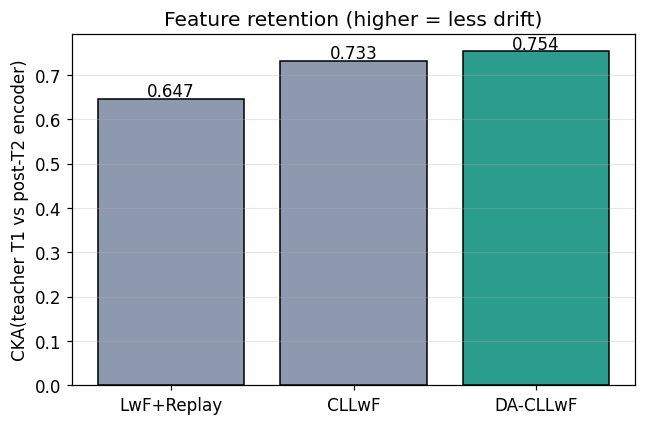

saved /content/drive/MyDrive/DACLLwF_results/figures/fig_cka_drift.png


In [56]:
### 14g. Feature-drift diagnostic (CKA) — does DAM reduce representation drift?

@torch.no_grad()
def mean_feat(model,loader,task,mb=20):
    model.eval();
    if isinstance(model,DACLLwFSegModel) and model.use_dsbn: set_model_task(model,task)
    acc=[];nb=0
    for x,_,_ in loader:
        x=x.to(DEVICE); f=model.extract_features(x)[-1]
        acc.append(F.adaptive_avg_pool2d(f,1).flatten(1).cpu()); nb+=1
        if nb>=mb: break
    return torch.cat(acc,0)
def linear_cka(X,Y):
    X=X-X.mean(0,keepdim=True);Y=Y-Y.mean(0,keepdim=True)
    return ((X.t()@Y).norm()**2/((X.t()@X).norm()*(Y.t()@Y).norm()+1e-9)).item()
teach=DACLLwFSegModel(use_dsbn=False).to(DEVICE); teach.add_task('T1'); load_ckpt(teach,T1_TAG); teach.eval()
ref=mean_feat(teach,t1_test,'T1')
names=['replay_only','cllwf','dam_full']; ckas=[]
for name in names:
    tg=f'DAM_{name}_s{cfg.base_seed}'
    if not ckpt_exists(tg): ckas.append(np.nan); continue
    mv=DACLLwFSegModel(use_dsbn=VARIANTS[name]['use_dsbn']).to(DEVICE); mv.add_task('T1');mv.add_task('T2')
    load_ckpt(mv,tg); ckas.append(linear_cka(ref,mean_feat(mv,t1_test,'T1')))
fig,ax=plt.subplots(figsize=(6,4))
ax.bar([LABELS[n] for n in names],ckas,color=['#8d99ae','#8d99ae','#2a9d8f'],edgecolor='black')
ax.set_ylabel('CKA(teacher T1 vs post-T2 encoder)'); ax.set_title('Feature retention (higher = less drift)')
for i,v in enumerate(ckas):
    if not np.isnan(v): ax.text(i,v+0.005,f'{v:.3f}',ha='center')
ax.grid(axis='y',alpha=.3); plt.tight_layout()
plt.savefig(FIG_DIR/'fig_cka_drift.png',bbox_inches='tight'); plt.show(); print('saved',FIG_DIR/'fig_cka_drift.png')
del teach

In [57]:
## 13. Interpreting the result
# * **GO**: DAM is a claimable, non-incremental architectural contribution (it resolves the
#   distillation-vs-alignment conflict and the gain is significant). Next: rerun the 5 variants on
#   **Res2Net-50** and **MiT-B2**, add the alignment-weight sweep + MMD/DANN ablations, then write the
#   full paper. Lead with the *conflict-resolution insight*, not "we added CORAL".
# * **NO-GO**: keep the DSBN-vs-CORAL split and weight-sweep as an honest **analysis paper**
#   ("when does domain alignment help vs hurt heterogeneous continual segmentation").

# **Before trusting anything, confirm `replay_only` and `cllwf` reproduce your CLLwF paper numbers
# (T1_after ~0.8694, T2 ~0.8559 at seed 42) within noise.** If not, reconcile the base pipeline first.

variants found: ['replay_only', 'cllwf', 'dam_dsbn', 'dam_coral', 'dam_full']


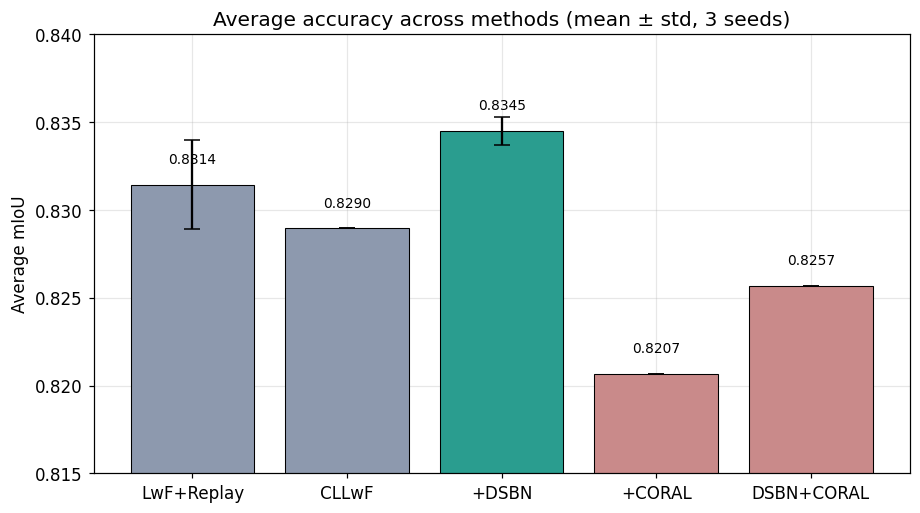

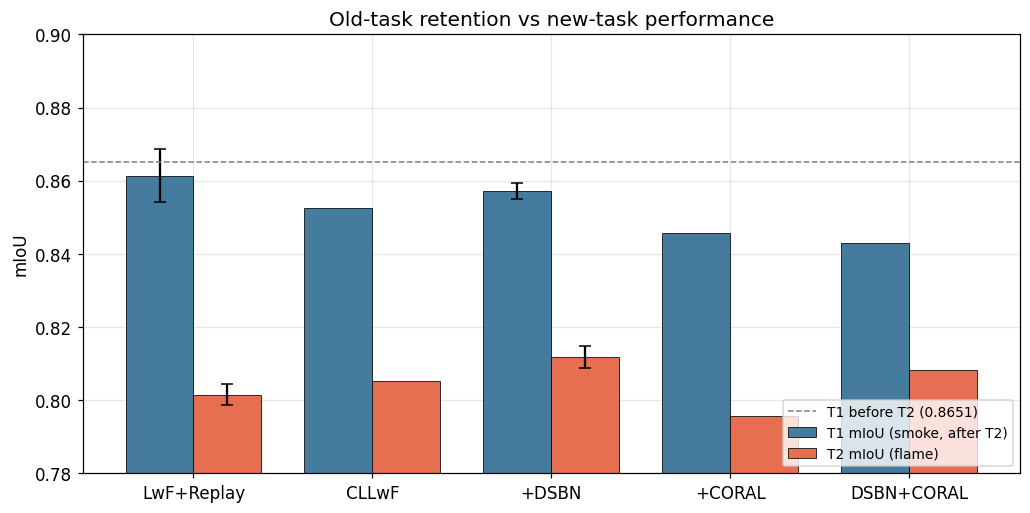

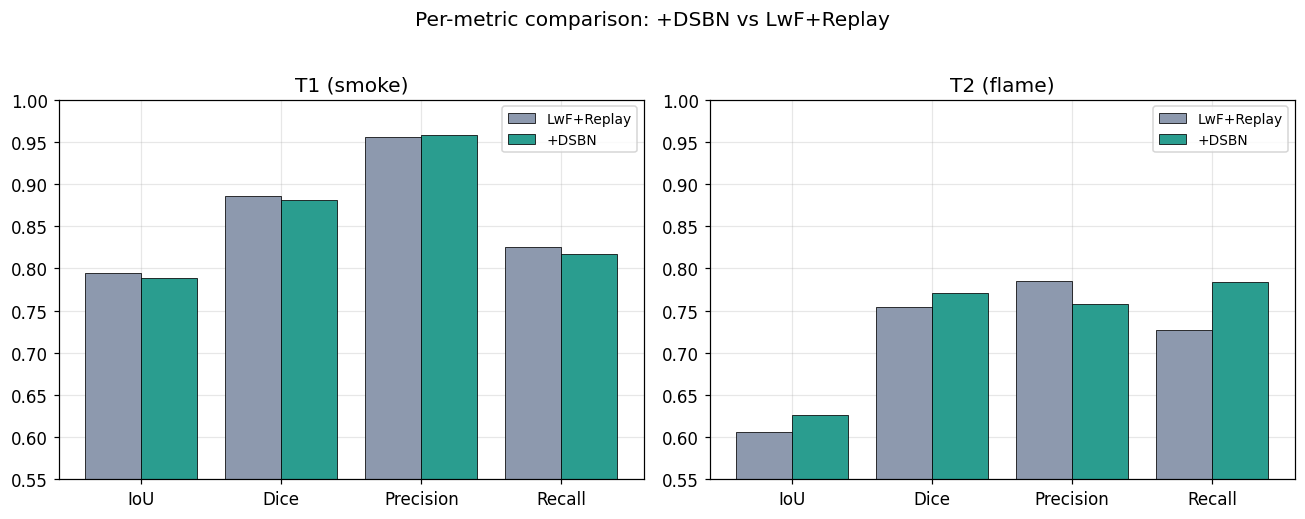

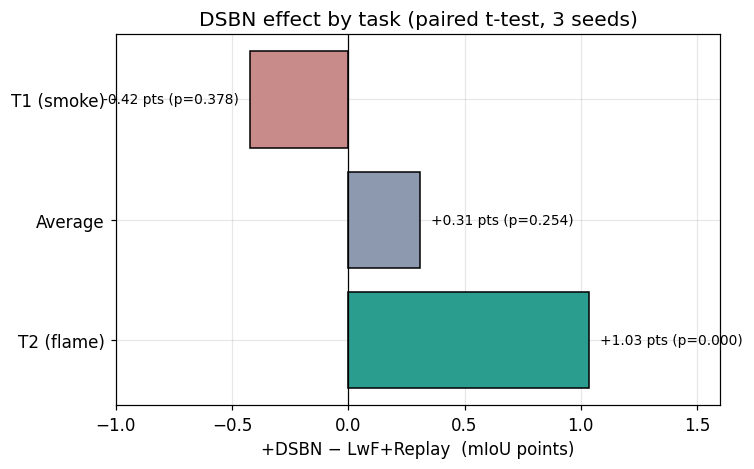

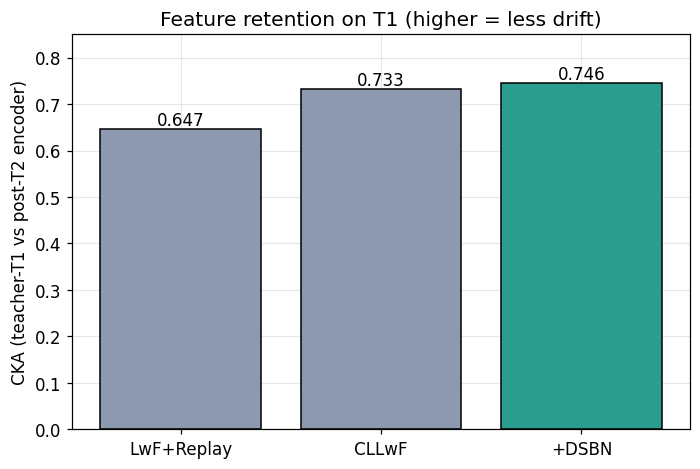

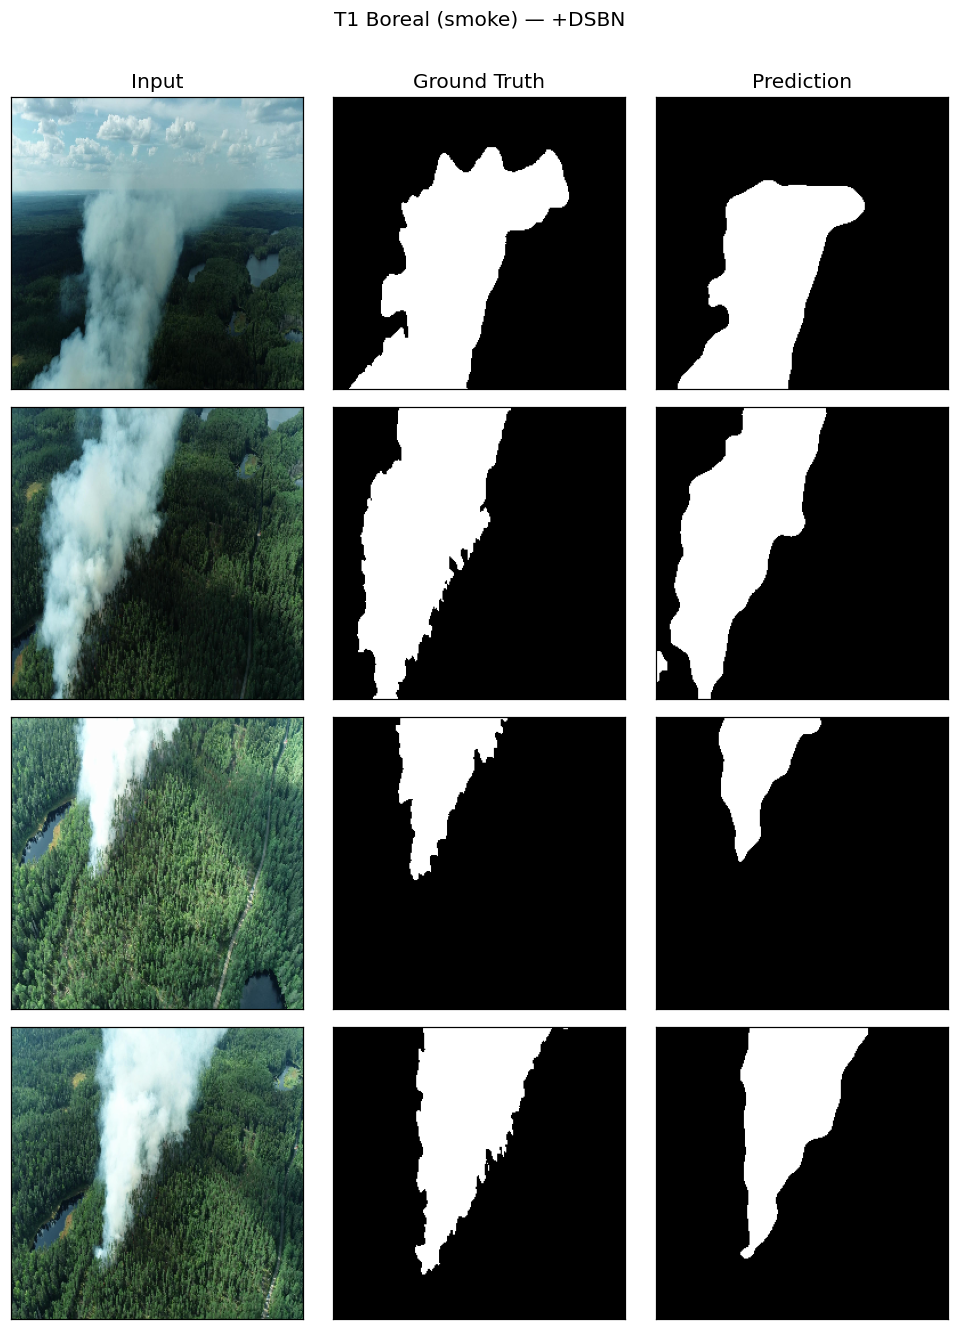

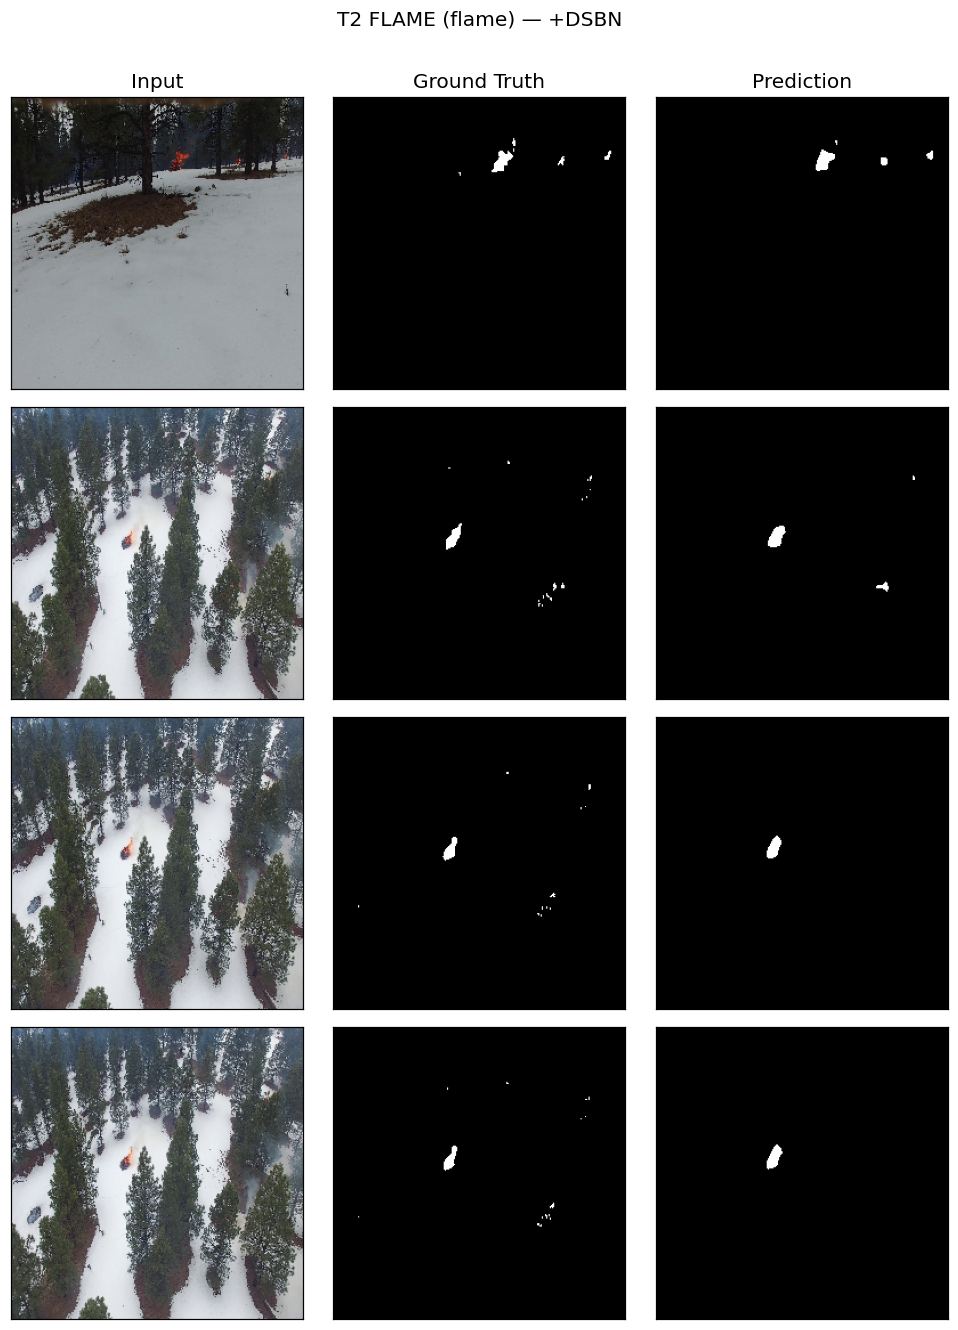


✅ All paper figures saved to: /content/drive/MyDrive/DACLLwF_results/figures/paper


In [58]:
# ═══════════════════════════════════════════════════════════════════════════
#  PAPER-READY FIGURES (honest framing) — regenerates all figures from saved
#  results. Uses +DSBN (dam_dsbn) as the useful variant, NOT dam_full.
#  Run this as the LAST cell. Figures saved to DACLLwF_results/figures/paper/
# ═══════════════════════════════════════════════════════════════════════════
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

plt.rcParams.update({'savefig.dpi':300,'font.size':11,'axes.grid':True,
                     'grid.alpha':0.3,'axes.axisbelow':True})
PAPER = FIG_DIR/'paper'; PAPER.mkdir(parents=True, exist_ok=True)

SEEDS = (42,43,44)
VLIST = ['replay_only','cllwf','dam_dsbn','dam_coral','dam_full']
LABEL = {'replay_only':'LwF+Replay','cllwf':'CLLwF','dam_dsbn':'+DSBN',
         'dam_coral':'+CORAL','dam_full':'DSBN+CORAL'}
USE_DSBN = {'replay_only':False,'cllwf':False,'dam_dsbn':True,'dam_coral':False,'dam_full':True}

# ---- load all per-seed results ----
recs=[]
for v in VLIST:
    for s in SEEDS:
        tag=f'DAM_{v}_s{s}'
        if res_exists(tag):
            r=load_res(tag)
            row={'variant':v,'seed':s,'T1_after':r['T1_after'],'T2':r['T2'],
                 'avg':r['avg'],'retention':r['retention']}
            for k in ['Dice_fg','precision','recall','IoU_fg']:
                row[f'T1_{k}']=r.get('T1_metrics',{}).get(k,np.nan)
                row[f'T2_{k}']=r.get('T2_metrics',{}).get(k,np.nan)
            recs.append(row)
D=pd.DataFrame(recs)
G=D.groupby('variant'); mean=G.mean(numeric_only=True).reindex(VLIST)
std=G.std(numeric_only=True).reindex(VLIST)
present=[v for v in VLIST if v in mean.index and not np.isnan(mean.loc[v,'avg'])]
print("variants found:", present)

# ==== FIG 1: average mIoU with error bars (mean±std over seeds) ====
xs=np.arange(len(present)); labs=[LABEL[v] for v in present]
cols=['#8d99ae','#8d99ae','#2a9d8f','#c98a8a','#8d99ae']
cols=[('#2a9d8f' if v=='dam_dsbn' else ('#c98a8a' if v in('dam_coral','dam_full') else '#8d99ae')) for v in present]
fig,ax=plt.subplots(figsize=(8.5,4.8))
bars=ax.bar(xs,[mean.loc[v,'avg'] for v in present],
            yerr=[std.loc[v,'avg'] if not np.isnan(std.loc[v,'avg']) else 0 for v in present],
            capsize=5,color=cols,edgecolor='black',linewidth=.7)
for i,v in enumerate(present):
    ax.text(i,mean.loc[v,'avg']+0.0012,f"{mean.loc[v,'avg']:.4f}",ha='center',fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(labs); ax.set_ylabel('Average mIoU')
ax.set_title('Average accuracy across methods (mean ± std, 3 seeds)')
ax.set_ylim(0.815,0.840)
plt.tight_layout(); plt.savefig(PAPER/'fig1_avg_accuracy.png',bbox_inches='tight'); plt.show()

# ==== FIG 2: T1 retention vs T2 (grouped) — the stability-plasticity story ====
w=0.38
fig,ax=plt.subplots(figsize=(9.5,4.8))
ax.bar(xs-w/2,[mean.loc[v,'T1_after'] for v in present],w,
       yerr=[std.loc[v,'T1_after'] or 0 for v in present],capsize=4,
       label='T1 mIoU (smoke, after T2)',color='#457b9d',edgecolor='black',linewidth=.5)
ax.bar(xs+w/2,[mean.loc[v,'T2'] for v in present],w,
       yerr=[std.loc[v,'T2'] or 0 for v in present],capsize=4,
       label='T2 mIoU (flame)',color='#e76f51',edgecolor='black',linewidth=.5)
ax.axhline(t1_before['mIoU'],ls='--',color='grey',lw=1,label=f"T1 before T2 ({t1_before['mIoU']:.4f})")
ax.set_xticks(xs); ax.set_xticklabels(labs); ax.set_ylabel('mIoU'); ax.legend(fontsize=9,loc='lower right')
ax.set_title('Old-task retention vs new-task performance'); ax.set_ylim(0.78,0.90)
plt.tight_layout(); plt.savefig(PAPER/'fig2_retention_vs_newtask.png',bbox_inches='tight'); plt.show()

# ==== FIG 3: per-metric — +DSBN vs LwF+Replay (the CORRECT comparison) ====
mets=['IoU_fg','Dice_fg','precision','recall']; nm=['IoU','Dice','Precision','Recall']
prop='dam_dsbn'; base='replay_only'
fig,ax=plt.subplots(1,2,figsize=(12,4.6))
for j,(task,pfx) in enumerate([('T1 (smoke)','T1_'),('T2 (flame)','T2_')]):
    xm=np.arange(len(mets))
    bv=[mean.loc[base,pfx+m] for m in mets]; pv=[mean.loc[prop,pfx+m] for m in mets]
    ax[j].bar(xm-0.2,bv,0.4,label='LwF+Replay',color='#8d99ae',edgecolor='black',linewidth=.5)
    ax[j].bar(xm+0.2,pv,0.4,label='+DSBN',color='#2a9d8f',edgecolor='black',linewidth=.5)
    ax[j].set_xticks(xm); ax[j].set_xticklabels(nm); ax[j].set_title(task)
    ax[j].set_ylim(0.55,1.0); ax[j].legend(fontsize=9)
plt.suptitle('Per-metric comparison: +DSBN vs LwF+Replay',y=1.02)
plt.tight_layout(); plt.savefig(PAPER/'fig3_metric_breakdown_DSBN.png',bbox_inches='tight'); plt.show()

# ==== FIG 4: significance summary (T2 gain, the significant result) ====
from scipy import stats
fig,ax=plt.subplots(figsize=(7,4.4))
metrics_sig=[('T2','T2 (flame)'),('avg','Average'),('T1_after','T1 (smoke)')]
diffs=[]; ps=[]; names=[]
for key,nmm in metrics_sig:
    b=D[D.variant==base].sort_values('seed')[key].values
    p_=D[D.variant==prop].sort_values('seed')[key].values
    d=p_.mean()-b.mean(); _,pv=stats.ttest_rel(p_,b)
    diffs.append(d*100); ps.append(pv); names.append(nmm)
colors=['#2a9d8f' if p<0.05 and dd>0 else '#c98a8a' if dd<0 else '#8d99ae' for dd,p in zip(diffs,ps)]
bars=ax.barh(names,diffs,color=colors,edgecolor='black')
for i,(dd,p) in enumerate(zip(diffs,ps)):
    ax.text(dd+(0.05 if dd>=0 else -0.05),i,f"{dd:+.2f} pts (p={p:.3f})",
            va='center',ha='left' if dd>=0 else 'right',fontsize=9)
ax.axvline(0,color='black',lw=.8); ax.set_xlabel('+DSBN − LwF+Replay  (mIoU points)')
ax.set_title('DSBN effect by task (paired t-test, 3 seeds)')
ax.set_xlim(-1.0,1.6)
plt.tight_layout(); plt.savefig(PAPER/'fig4_significance.png',bbox_inches='tight'); plt.show()

# ==== FIG 5: CKA feature-drift (already good — regenerate clean) ====
import torch.nn.functional as F
@torch.no_grad()
def mean_feat(model,loader,task,mb=20):
    model.eval()
    if isinstance(model,DACLLwFSegModel) and model.use_dsbn: set_model_task(model,task)
    acc=[];nb=0
    for x,_,_ in loader:
        x=x.to(DEVICE); f=model.extract_features(x)[-1]
        acc.append(F.adaptive_avg_pool2d(f,1).flatten(1).cpu());nb+=1
        if nb>=mb: break
    return torch.cat(acc,0)
def cka(X,Y):
    X=X-X.mean(0,keepdim=True);Y=Y-Y.mean(0,keepdim=True)
    return ((X.t()@Y).norm()**2/((X.t()@X).norm()*(Y.t()@Y).norm()+1e-9)).item()
teach=DACLLwFSegModel(use_dsbn=False).to(DEVICE); teach.add_task('T1'); load_ckpt(teach,T1_TAG); teach=teach.to(DEVICE); teach.eval()
ref=mean_feat(teach,t1_test,'T1')
cka_names=['replay_only','cllwf','dam_dsbn']; ckas=[]
for v in cka_names:
    tg=f'DAM_{v}_s{cfg.base_seed}'
    if not ckpt_exists(tg): ckas.append(np.nan); continue
    mv=DACLLwFSegModel(use_dsbn=USE_DSBN[v]).to(DEVICE); mv.add_task('T1');mv.add_task('T2')
    load_ckpt(mv,tg); mv=mv.to(DEVICE)
    ckas.append(cka(ref,mean_feat(mv,t1_test,'T1')))
fig,ax=plt.subplots(figsize=(6.5,4.4))
cc=['#8d99ae','#8d99ae','#2a9d8f']
b=ax.bar([LABEL[v] for v in cka_names],ckas,color=cc,edgecolor='black')
for i,v in enumerate(ckas):
    if not np.isnan(v): ax.text(i,v+0.008,f'{v:.3f}',ha='center')
ax.set_ylabel('CKA (teacher-T1 vs post-T2 encoder)')
ax.set_title('Feature retention on T1 (higher = less drift)'); ax.set_ylim(0,0.85)
plt.tight_layout(); plt.savefig(PAPER/'fig5_cka_drift.png',bbox_inches='tight'); plt.show()
del teach

# ==== FIG 6: qualitative predictions — +DSBN (dam_dsbn) ====
import cv2
@torch.no_grad()
def qualitative(tag,pairs,task,n=4,fname='qual.png',title='',use_dsbn=True):
    if not ckpt_exists(tag): print('no ckpt',tag); return
    m=DACLLwFSegModel(use_dsbn=use_dsbn).to(DEVICE); m.add_task('T1');m.add_task('T2')
    load_ckpt(m,tag); m=m.to(DEVICE); m.eval()
    tf=eval_tf(cfg.img_size); sel=pairs[:n]; im=np.array(IM); s_=np.array(IS)
    fig,ax=plt.subplots(n,3,figsize=(9,3*n))
    for i,(ip,mp) in enumerate(sel):
        img=np.array(Image.open(ip).convert('RGB')); gt=(np.array(Image.open(mp).convert('L'))>0).astype('uint8')
        o=tf(image=img,mask=gt); x=o['image'][None].to(DEVICE)
        pr=m(x,task).argmax(1)[0].cpu().numpy()
        disp=(o['image'].permute(1,2,0).cpu().numpy()*s_+im).clip(0,1)
        gtr=cv2.resize(gt,(cfg.img_size,cfg.img_size),interpolation=cv2.INTER_NEAREST)
        ax[i,0].imshow(disp);ax[i,1].imshow(gtr,cmap='gray');ax[i,2].imshow(pr,cmap='gray')
        for k,t in enumerate(['Input','Ground Truth','Prediction']):
            ax[i,k].set_xticks([]);ax[i,k].set_yticks([])
            if i==0: ax[i,k].set_title(t)
    plt.suptitle(title,y=1.005); plt.tight_layout()
    plt.savefig(PAPER/fname,bbox_inches='tight'); plt.show()
best=f'DAM_dam_dsbn_s{cfg.base_seed}'
qualitative(best,b_te,'T1',4,'fig6a_qual_smoke.png','T1 Boreal (smoke) — +DSBN',True)
qualitative(best,f_te,'T2',4,'fig6b_qual_flame.png','T2 FLAME (flame) — +DSBN',True)

print('\n✅ All paper figures saved to:', PAPER)